
## preprocessing
The dataset was first loaded and inspected to understand its structure, data types, and size.

Duplicate records were removed to prevent biased learning and repeated observations.

The target variable default payment next month was renamed to default for clarity.

The ID column was dropped since it serves only as an identifier and has no predictive value.

Invalid categories in EDUCATION and MARRIAGE were grouped into an “Other” category to ensure data consistency.

The cleaned dataset was prepared for exploratory data analysis and modeling.

In [1]:
import pandas as pd
import numpy as np
# Load the Excel dataset (header=1 is used because first row contains a description/title)
df = pd.read_excel("default of credit card clients.xls", header=1)

# Preview first 5 rows
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
# Check dataset size and column types
print("Rows, Columns:", df.shape)
df.info()

# Check missing values
print("\nMissing values per column:\n", df.isnull().sum())


Rows, Columns: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 

In [3]:
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)

# Rename target column for convenience
df.rename(columns={"default payment next month": "default"}, inplace=True)

# Drop ID column (identifier, not useful for prediction)
df.drop(columns=["ID"], inplace=True)

# Check dataset shape after cleaning
print("Shape after removing duplicates and ID:", df.shape)


Shape after removing duplicates and ID: (30000, 24)


In [4]:
# EDUCATION: Replace invalid categories (0, 5, 6) with 'Other' (4)
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)

# MARRIAGE: Replace invalid category (0) with 'Other' (3)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

# Verify cleaned categories
print("EDUCATION values:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE values:", sorted(df["MARRIAGE"].unique()))


EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values: [np.int64(1), np.int64(2), np.int64(3)]


The distribution of the target variable was analyzed to understand class imbalance between defaulters and non-defaulters.

A correlation heatmap was used to examine relationships among numerical variables and identify strongly related features.

Repayment status variables were analyzed to study their impact on default behavior.

Credit limit distributions were compared between defaulters and non-defaulters to assess financial risk patterns.

Age distribution was analyzed to explore demographic differences in default behavior.

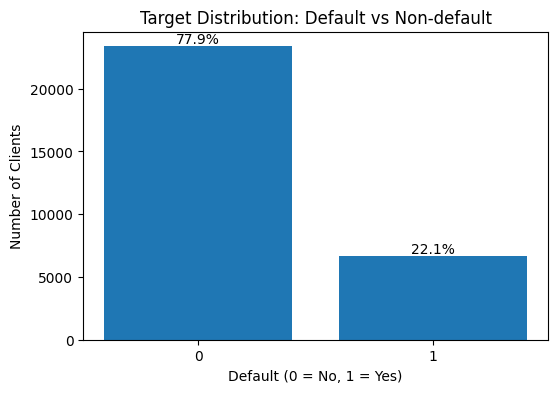

In [5]:
import matplotlib.pyplot as plt

# Count and percentage of classes
counts = df["default"].value_counts()
percent = df["default"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target Distribution: Default vs Non-default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")

# Add percentage labels
for i, (c, p) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, c, f"{p:.1f}%", ha="center", va="bottom")

plt.show()


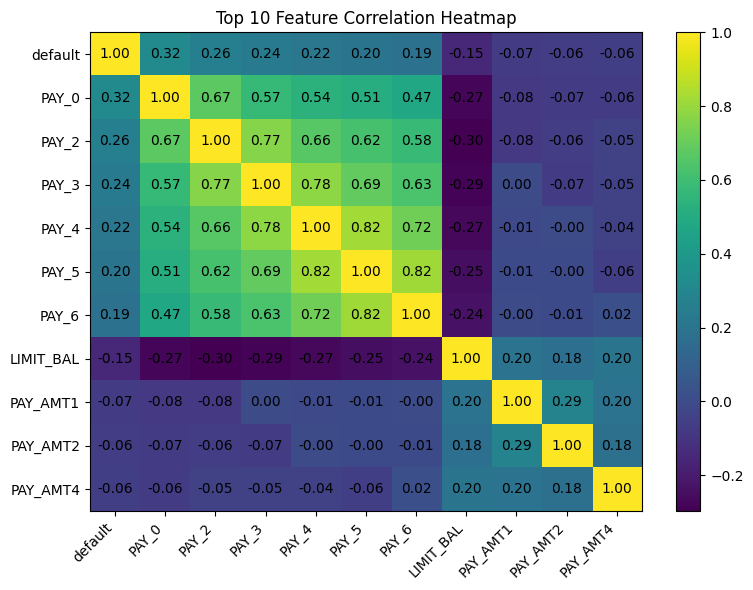

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Select top 10 features most correlated with the target
top_features = (
    corr["default"]
    .abs()
    .sort_values(ascending=False)
    .head(11)   # includes 'default' itself
    .index
)

# Subset correlation matrix
top_corr = corr.loc[top_features, top_features]

# Plot heatmap
plt.figure(figsize=(8,6))
im = plt.imshow(top_corr, aspect="auto")
plt.colorbar(im)
plt.title("Top 10 Feature Correlation Heatmap")

# Axis labels
plt.xticks(range(len(top_corr.columns)), top_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(top_corr.columns)), top_corr.columns)

# Annotate correlation values on each cell
for i in range(len(top_corr)):
    for j in range(len(top_corr)):
        plt.text(
            j, i,
            f"{top_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()
